# Galton 風 親子身長（cm） — シミュレーションと回帰分析（ちゃんぽん説明付き）

このノートブックは、Galton に触発された「親の身長（mid‑parent）→ 子の身長」を cm 単位でシミュレーションし、単回帰（Ordinary Least Squares; OLS）を行います。
- 散布図（scatter plot）に回帰直線を描き、傾き（slope）と R² を注記します。
- statsmodels の回帰サマリー（coefficients, std err, t, p, R², adjusted R²）を表示します。
- インタラクティブ部品（ipywidgets）で「極端な親の身長を選ぶ → 多数の子をシミュレーション」して、平均が親の値に比べて母平均へ戻る（regression toward the mean）様子を“見る”ことができます。

※ キー用語は日本語の後に英語（括弧）表記します。ところどころ「ちゃんぽん」を混ぜます.

In [1]:
# ライブラリ読み込み
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from ipywidgets import interact, FloatSlider, IntSlider, fixed, VBox, HBox
from IPython.display import clear_output

sns.set(style='whitegrid')
np.random.seed(2025)

## シミュレーション設定（cm 単位）

- 親の平均（mid-parent mean）: 68 in × 2.54 = 約 172.72 cm
- 標準偏差（parent sd）: 2.8 in × 2.54 = 約 7.11 cm
- 真の傾き（true slope）: 0.50（Galton 的には平均への回帰を示す値の一例）
- 真の切片（true intercept）: 32 in × 2.54 = 約 81.28 cm
- 残差の標準偏差（noise sd）: 2.5 in × 2.54 = 約 6.35 cm

In [2]:
# シミュレーション実行（cm 単位に変換済みの値を使用）
N = 300
parent_mean_cm = 68.0 * 2.54  # 172.72 cm
parent_sd_cm = 2.8 * 2.54     # ~7.112 cm
true_slope = 0.50
true_intercept_cm = 32.0 * 2.54  # ~81.28 cm
noise_sd_cm = 2.5 * 2.54       # ~6.35 cm

parent_cm = np.random.normal(parent_mean_cm, parent_sd_cm, size=N)
child_cm = true_intercept_cm + true_slope * parent_cm + np.random.normal(0, noise_sd_cm, size=N)

df = pd.DataFrame({'parent_cm': parent_cm, 'child_cm': child_cm})
df.head()

,parent_cm,child_cm
0,172.062921,163.337491
1,177.942239,169.885405
2,162.486671,162.999438
3,168.001743,157.911477
4,172.003622,164.939039


In [3]:
# OLS 回帰（statsmodels）
X = sm.add_constant(df['parent_cm'])
model = sm.OLS(df['child_cm'], X).fit()

intercept_hat = model.params['const']
slope_hat = model.params['parent_cm']
r2 = model.rsquared
adj_r2 = model.rsquared_adj

print(f'推定切片（intercept）: {intercept_hat:.4f} cm')
print(f'推定傾き（slope）: {slope_hat:.4f} (cm per cm、単位はちゃんぽんで同じ)')
print(f'R²: {r2:.4f}')
print(f'Adjusted R²: {adj_r2:.4f}')
print('\n--- statsmodels summary ---')
print(model.summary())

推定切片（intercept）: 72.7255 cm
推定傾き（slope）: 0.5464 (cm per cm、単位はちゃんぽんで同じ)
R²: 0.2765
Adjusted R²: 0.2741

--- statsmodels summary ---
                            OLS Regression Results                            
Dep. Variable:               child_cm   R-squared:                       0.277
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     113.9
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           9.88e-23
Time:                        21:05:12   Log-Likelihood:                -963.16
No. Observations:                 300   AIC:                             1930.
Df Residuals:                     298   BIC:                             1938.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]

/var/folders/r2/8crk13rd1136ng21r3d8twg00000gn/T/ipykernel_3485/2774538181.py:18: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r2/8crk13rd1136ng21r3d8twg00000gn/T/ipykernel_3485/2774538181.py:18: UserWarning: Glyph 35242 (\N{CJK UNIFIED IDEOGRAPH-89AA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r2/8crk13rd1136ng21r3d8twg00000gn/T/ipykernel_3485/2774538181.py:18: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r2/8crk13rd1136ng21r3d8twg00000gn/T/ipykernel_3485/2774538181.py:18: UserWarning: Glyph 36523 (\N{CJK UNIFIED IDEOGRAPH-8EAB}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r2/8crk13rd1136ng21r3d8twg00000gn/T/ipykernel_3485/2774538181.py:18: UserWarning: Glyph 38263 (\N{CJK UNIFIED IDEOGRAPH-9577}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/r2/8crk13rd1136ng21r3d8twg00000gn/T/ipykernel_3485/2774538

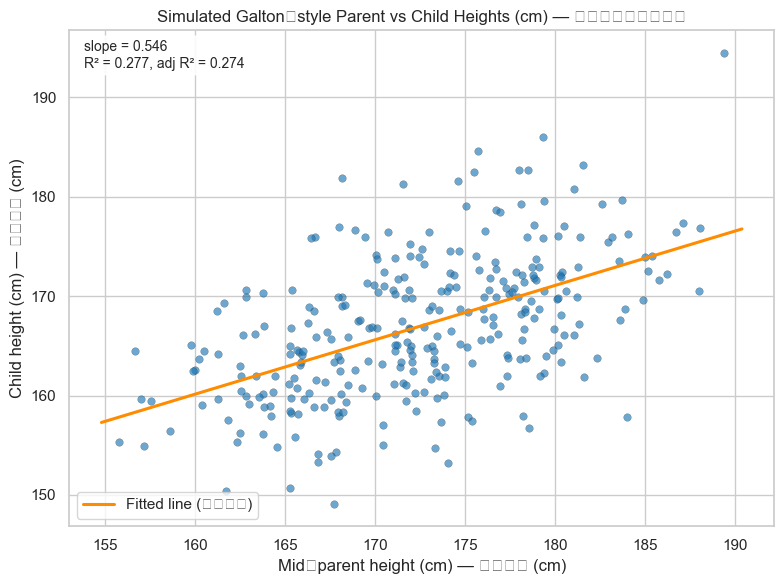

In [4]:
# 散布図 + 回帰直線（cm）
plt.figure(figsize=(8,6))
plt.scatter(df['parent_cm'], df['child_cm'], s=30, alpha=0.65, color='tab:blue', edgecolor='k', linewidth=0.2)

x_vals = np.linspace(df['parent_cm'].min() - 1, df['parent_cm'].max() + 1, 200)
y_vals = intercept_hat + slope_hat * x_vals
plt.plot(x_vals, y_vals, color='darkorange', linewidth=2.2, label='Fitted line (回帰直線)')

slope_text = f'slope = {slope_hat:.3f}'
r2_text = f'R² = {r2:.3f}, adj R² = {adj_r2:.3f}'
plt.text(0.02, 0.98, slope_text + '\n' + r2_text, transform=plt.gca().transAxes,
         verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.xlabel('Mid‑parent height (cm) — 親の身長 (cm)')
plt.ylabel('Child height (cm) — 子の身長 (cm)')
plt.title('Simulated Galton‑style Parent vs Child Heights (cm) — ちゃんぽんプロット')
plt.legend()
plt.tight_layout()
plt.show()

## 解説（日本語 + 英語キーワード）

- 傾き (slope): 親の身長が 1 cm 上がると、子の身長は平均で slope cm（ここでは約 0.5 cm）上がるという意味です。
- 切片 (intercept): 親の身長が 0 のときの予測子の身長（通常は意味を持たない）。
- R² (coefficient of determination): 説明変数（親の身長）が従属変数（子の身長）の分散をどれだけ説明しているか（0〜1）。
- Adjusted R² (調整済みR²): 説明変数の数とサンプル数に応じて R² を調整したもの。モデル比較で有用。
- 標準誤差, t 値, p 値 (std err, t, p): 推定量の不確実性と有意性を示します。

これらの値は上の model.summary() に全て出力されています。ちゃんぽん混ぜながら、傾きの値が 1 より小さい（0.5 程度）であることが「平均への回帰 (regression toward the mean)」の定性的証拠になります。

## インタラクティブ：特定の親の身長を選んで子の分布を見る（regression toward the mean を“見る”）

操作方法（How to use）:
- スライダーで親の身長（cm）を選択 → その親に対して多数の子をシミュレーションしてヒストグラムで表示します。
- 表示される「子の平均」は親の値に比べて母平均（population mean）に引き寄せられている（回帰）ことが分かります。

In [5]:
population_mean = df['parent_cm'].mean()  # mid‑parent の母平均（近似）

def show_child_distribution_for_parent(selected_parent_cm, n_children=500):
    """同じ親の身長を固定して n_children 人の子をシミュレートし、分布と平均値を表示する"""
    # 子の平均（理論的予測）
    predicted_child_mean = intercept_hat + slope_hat * selected_parent_cm
    # 子の個別値をシミュレート（残差分散を用いる）
    simulated_children = np.random.normal(predicted_child_mean, noise_sd_cm, size=n_children)

    # 描画
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(8,4))
    ax.hist(simulated_children, bins=30, color='skyblue', edgecolor='k', alpha=0.8)
    ax.axvline(predicted_child_mean, color='purple', linewidth=2, linestyle='--', label=f'Predicted mean = {predicted_child_mean:.2f} cm')
    ax.axvline(population_mean, color='orange', linewidth=2, linestyle=':', label=f'Population mean (parents) = {population_mean:.2f} cm')
    ax.axvline(selected_parent_cm, color='red', linewidth=2, linestyle='-', label=f'Selected parent = {selected_parent_cm:.2f} cm')

    ax.set_title(f'Selected parent: {selected_parent_cm:.1f} cm → simulated children (n={n_children})')
    ax.set_xlabel('Child height (cm) — 子の身長')
    ax.set_ylabel('Count')
    ax.legend()
    plt.tight_layout()
    plt.show()

# インタラクティブなスライダー（親の身長を選ぶ）
parent_slider = FloatSlider(value=population_mean, min=population_mean-25, max=population_mean+25, step=0.5, description='親の身長 (cm)')
interact(show_child_distribution_for_parent, selected_parent_cm=parent_slider, n_children=fixed(1000));


interactive(children=(FloatSlider(value=172.4383955082294, description='親の身長 (cm)', max=197.4383955082294, min…

## インタラクティブ（証明）: 極端な親身長を選んだときの多数回シミュレーションで "平均への回帰" を確認する

次のウィジェットでは、極端に低い/高い親の身長を選び、その親の下で多くの子を生成して子の平均を何度も計算します。複数回の試行で平均が親の値に比べて母平均（population mean）に近づく（回帰する）様子を可視化します。

In [ ]:
def demonstrate_regression_to_mean(selected_parent_cm, trials=100, n_children_per_trial=200):
    """selected_parent_cm を固定して trials 回、n_children_per_trial 人の子をシミュレート。
    各試行ごとの子の平均をプロットする（点が母平均へ引き寄せられるかを見る）
    """
    means = []
    for _ in range(trials):
        pred = intercept_hat + slope_hat * selected_parent_cm
        samp = np.random.normal(pred, noise_sd_cm, size=n_children_per_trial)
        means.append(np.mean(samp))

    # 描画
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(8,4))
    ax.plot(range(1, trials+1), means, marker='o', linestyle='-', color='tab:blue', alpha=0.7)
    ax.axhline(population_mean, color='orange', linestyle=':', linewidth=2, label=f'Population mean (parents) = {population_mean:.2f} cm')
    ax.axhline(selected_parent_cm, color='red', linestyle='-', linewidth=2, label=f'Selected parent = {selected_parent_cm:.2f} cm')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Mean child height (cm)')
    ax.set_title('Multiple trials: mean of simulated children (selected parent fixed)')
    ax.legend()
    plt.tight_layout()
    plt.show()

parent_extreme_slider = FloatSlider(value=population_mean+15, min=population_mean-25, max=population_mean+25, step=0.5, description='極端な親 (cm)')
trials_slider = IntSlider(value=50, min=10, max=200, step=10, description='試行回数')
nchildren_slider = IntSlider(value=200, min=50, max=2000, step=50, description='各試行の子数')

ui = VBox([parent_extreme_slider, HBox([trials_slider, nchildren_slider])])
out = interact(demonstrate_regression_to_mean, selected_parent_cm=parent_extreme_slider, trials=trials_slider, n_children_per_trial=nchildren_slider);

interactive(children=(FloatSlider(value=187.4383955082294, description='極端な親 (cm)', max=197.4383955082294, min…

## まとめ（Summary） — 日本語（English keywords）ちゃんぽん版

- 平均への回帰 (regression toward the mean): 極端な親（非常に高い／低い）を選ぶと、子の平均は親の値ほど極端にならず母平均へ近づく傾向が観察できます。
- R² / Adjusted R²: モデルの説明力を示します。R² が高いほど説明できる割合が大きいですが、変数を増やすと単純に上がる点に注意（Adjusted R² は調整済み）。
- ここで示したインタラクティブは「可視化による理解」に重きを置いています — 数値的検定（p 値等）と合わせて解釈してください。

必要なら、このノートブックを `kaiki2.ipynb` に上書き保存しておきますか？それともこのまま `galton_regression_cm.ipynb` を使いますか？